In [1]:
import matplotlib.pyplot as plt
import numpy as np

from astropy.visualization import time_support

from sunpy import timeseries as ts
from sunpy.net import Fido
from sunpy.net import attrs as a

from stixpy.net.client import STIXClient
from stixpy.timeseries import quicklook 

import datetime as dt
from sunpy.time import parse_time
from sunpy.time import TimeRange
from astropy.time import Time

import pandas as pd

In [2]:
lf_query = Fido.search(a.Time('2024-10-03T12:04:29.984', '2024-10-03T13:15:41.992'), 
                       a.Instrument.stix, 
                       a.stix.DataProduct.ql_lightcurve)

lf_file = Fido.fetch(lf_query)

lf_lc = ts.TimeSeries(lf_file)
lf_df = lf_lc.to_dataframe()

Files Downloaded:   0%|          | 0/1 [00:00<?, ?file/s]

In [4]:
goes_lf_result = Fido.search(a.Time('2024-10-03T12:04:29.984', '2024-10-03T13:15:41.992'),
                     a.Instrument("XRS"),
                     a.goes.SatelliteNumber(16))

goes_lf_files = Fido.fetch(goes_lf_result)

goes_lf = ts.TimeSeries(goes_lf_files, concatenate=True)
goes_lf_df = goes_lf.to_dataframe()

Files Downloaded:   0%|          | 0/2 [00:00<?, ?file/s]

In [61]:
tstart.datetime.month

10

In [5]:
working_df = lf_df.copy()

earth_tdel = lf_lc.meta.metas[0]["EAR_TDEL"]
shifted_times = lf_lc.time+dt.timedelta(seconds=earth_tdel)
working_df.index = shifted_times

tstart = parse_time('2024-10-03T12:04:29.984')
tstart_s = tstart+dt.timedelta(seconds=earth_tdel)

tend = parse_time('2024-10-03T13:15:41.992')
tend_s = tend+dt.timedelta(seconds=earth_tdel)

tr=TimeRange(tstart_s, tend_s)

In [9]:
stix_df = working_df.truncate(tstart_s.datetime, tend_s.datetime)
goes_df = goes_lf_df.truncate(tstart_s.datetime, tend_s.datetime)

In [19]:
stix_df

,control_index,timedel,triggers,triggers_comp_err,rcr,4-10 keV,10-15 keV,15-25 keV,25-50 keV,50-84 keV,4-10 keV_comp_err,10-15 keV_comp_err,15-25 keV_comp_err,25-50 keV_comp_err,50-84 keV_comp_err
2024-10-03 12:10:21.971,20,400.0,23551,591.206787,0,728.571760,80.311570,3.390263,6.097451,2.474375,591.206787,36.952671,4.636809,18.479719,9.246621
2024-10-03 12:10:25.971,20,400.0,23551,591.206787,0,728.571760,73.882626,3.390263,6.740346,2.238017,591.206787,36.952671,4.636809,18.479719,9.246621
2024-10-03 12:10:29.971,20,400.0,23551,591.206787,0,728.571760,73.882626,2.888002,6.097451,2.001659,591.206787,36.952671,2.345208,18.479719,9.246621
2024-10-03 12:10:33.971,20,400.0,25599,591.206787,0,728.858396,80.343166,2.889138,6.742997,2.238897,591.206787,36.952671,2.345208,18.479719,9.246621
2024-10-03 12:10:37.971,20,400.0,25599,591.206787,0,814.611368,73.911693,2.889138,6.099850,2.475349,591.206787,36.952671,2.345208,18.479719,9.246621
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-10-03 13:21:13.971,22,400.0,86015,2364.826660,0,2949.792741,136.595937,3.126405,6.171473,2.265186,2364.826660,73.901962,2.345208,18.479719,9.246621
2024-10-03 13:21:17.971,22,400.0,86015,2364.826660,0,2949.792741,136.595937,3.838107,6.171473,2.265186,2364.826660,73.901962,4.636809,18.479719,9.246621
2024-10-03 13:21:21.971,22,400.0,86015,2364.826660,0,2949.792741,149.609916,3.431420,6.171473,2.265186,2364.826660,73.901962,4.636809,18.479719,9.246621
2024-10-03 13:21:25.971,22,400.0,86015,2364.826660,0,2949.792741,149.609916,3.431420,6.171473,2.265186,2364.826660,73.901962,4.636809,18.479719,9.246621


In [20]:
goes_df

,xrsa,xrsb,xrsa_quality,xrsb_quality,xrsa_primary_chan,xrsb_primary_chan
2024-10-03 12:10:20.270081,3.687062e-07,0.000009,0,0,1.0,1.0
2024-10-03 12:10:21.270083,3.794934e-07,0.000009,0,0,1.0,1.0
2024-10-03 12:10:22.270086,3.892177e-07,0.000009,0,0,1.0,1.0
2024-10-03 12:10:23.270084,3.816509e-07,0.000009,0,0,1.0,1.0
2024-10-03 12:10:24.270089,3.816667e-07,0.000009,0,0,1.0,1.0
...,...,...,...,...,...,...
2024-10-03 13:21:27.281991,9.627746e-07,0.000014,0,0,1.0,1.0
2024-10-03 13:21:28.281994,9.681681e-07,0.000014,0,0,1.0,1.0
2024-10-03 13:21:29.282000,9.649483e-07,0.000014,0,0,1.0,1.0
2024-10-03 13:21:30.282001,9.660270e-07,0.000014,0,0,1.0,1.0


In [10]:
pd.options.plotting.backend = 'matplotlib'

In [34]:
print(stix_df.index.dtype)
print(goes_df.index.dtype)

datetime64[us]
datetime64[us]


In [33]:
stix_df.index = parse_time(stix_df.index).datetime
goes_df.index = parse_time(goes_df.index).datetime

In [36]:
att_in_index = np.where(stix_df['rcr']!=0)
starts=[]
for n in range((np.shape(att_in_index))[1]):
    # if n==0:
    #     starts.append(att_in_index[0][n])
    if att_in_index[0][n]!=1+att_in_index[0][n-1]:
        starts.append(att_in_index[0][n])

ends=[]
for n in range((np.shape(att_in_index))[1]):
    if n==(np.shape(att_in_index))[1]-1:
        ends.append(att_in_index[0][n])
        break
    elif att_in_index[0][n]!=att_in_index[0][n+1]-1:
        ends.append(att_in_index[0][n])

start_end = list(zip(starts, ends))

In [45]:
stix_df.index[starts[0]]

Timestamp('2024-10-03 12:14:49.971432')

In [44]:
stix_df.loc[stix_df.index[0]]

control_index            20.000000
timedel                 400.000000
triggers              23551.000000
triggers_comp_err       591.206787
rcr                       0.000000
4-10 keV                728.571760
10-15 keV                80.311570
15-25 keV                 3.390263
25-50 keV                 6.097451
50-84 keV                 2.474375
4-10 keV_comp_err       591.206787
10-15 keV_comp_err       36.952671
15-25 keV_comp_err        4.636809
25-50 keV_comp_err       18.479719
50-84 keV_comp_err        9.246621
Name: 2024-10-03 12:10:21.971432, dtype: float64

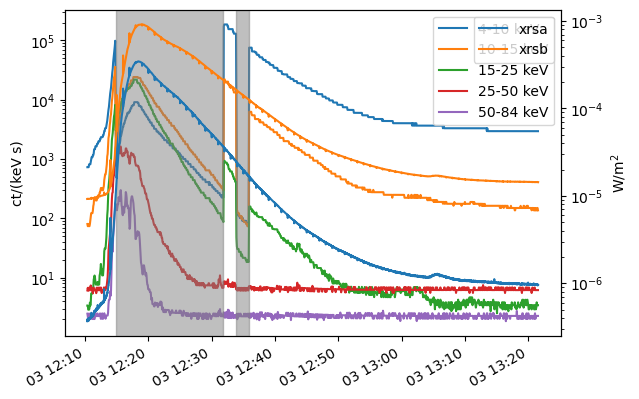

In [48]:
fig, ax = plt.subplots()
ax.set_yscale('log')
ax.set_ylabel('ct/(keV s)')
stix_df.plot(ax=ax, y='4-10 keV')
stix_df.plot(ax=ax, y='10-15 keV')
stix_df.plot(ax=ax, y='15-25 keV')
stix_df.plot(ax=ax, y='25-50 keV')
stix_df.plot(ax=ax, y='50-84 keV')

goes_ax = ax.twinx()
goes_ax.set_yscale('log')
goes_ax.set_ylabel('W/m$^{2}$')

goes_df.plot(ax=goes_ax, y='xrsa')
goes_df.plot(ax=goes_ax, y='xrsb')

for pair in start_end:
    plt.axvspan(stix_df.index[pair[0]], stix_df.index[pair[1]], color='grey', alpha=0.5)

In [63]:
flares = pd.read_csv("C:/Users/derva/OneDrive/Documents/DIAS/solar-orbiter-flare-statistics/data/STIX_flarelist_w_locations_20210101_20260130_version1_python.csv")

In [64]:
start_time_test = '2024-10-03T12:04:29.984'
baseline_410 = flares.loc[flares['start_UTC'] == start_time_test, 'bkg 4-10 keV'].values[0]
baseline_1015 = flares.loc[flares['start_UTC'] == start_time_test, 'bkg 10-15 keV'].values[0]
baseline_1525 = flares.loc[flares['start_UTC'] == start_time_test, 'bkg 15-25 keV'].values[0]
baseline_2550 = flares.loc[flares['start_UTC'] == start_time_test, 'bkg 25-50 keV'].values[0]
baseline_5084 = flares.loc[flares['start_UTC'] == start_time_test, 'bkg 50-84 keV'].values[0]

In [67]:
stix_df_baselinesubtracted = stix_df.copy()
stix_df_baselinesubtracted['4-10 keV'] = stix_df_baselinesubtracted['4-10 keV'] - baseline_410
stix_df_baselinesubtracted['10-15 keV'] = stix_df_baselinesubtracted['10-15 keV'] - baseline_1015
stix_df_baselinesubtracted['15-25 keV'] = stix_df_baselinesubtracted['15-25 keV'] - baseline_1525
stix_df_baselinesubtracted['25-50 keV'] = stix_df_baselinesubtracted['25-50 keV'] - baseline_2550
stix_df_baselinesubtracted['50-84 keV'] = stix_df_baselinesubtracted['50-84 keV'] - baseline_5084

In [70]:
goes_df_baselinesubtracted = goes_df.copy()


<Axes: ylabel='W/m$^{2}$'>

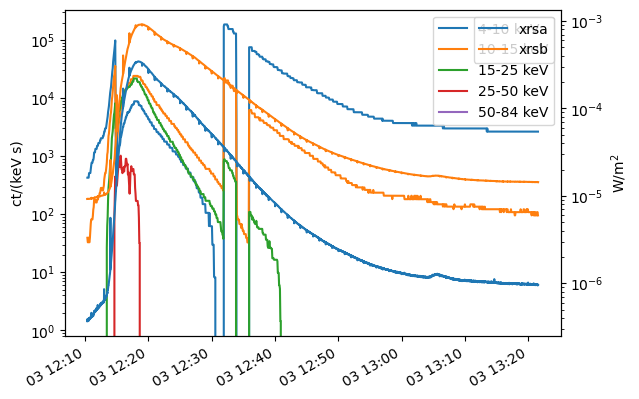

In [71]:
fig, ax = plt.subplots()
ax.set_yscale('log')
ax.set_ylabel('ct/(keV s)')
stix_df_baselinesubtracted.plot(ax=ax, y='4-10 keV')
stix_df_baselinesubtracted.plot(ax=ax, y='10-15 keV')
stix_df_baselinesubtracted.plot(ax=ax, y='15-25 keV')
stix_df_baselinesubtracted.plot(ax=ax, y='25-50 keV')
stix_df_baselinesubtracted.plot(ax=ax, y='50-84 keV')

goes_ax = ax.twinx()
goes_ax.set_yscale('log')
goes_ax.set_ylabel('W/m$^{2}$')

goes_df.plot(ax=goes_ax, y='xrsa')
goes_df.plot(ax=goes_ax, y='xrsb')

# for pair in start_end:
#     plt.axvspan(stix_df.index[pair[0]], stix_df.index[pair[1]], color='grey', alpha=0.5)